<a href="https://colab.research.google.com/github/swoodge/hse_dl_2026_homeworks/blob/main/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework part I

The first problem set contains basic tasks in PyTorch.

__Note:__ Instead of doing this part of homework, you can prove your skills otherwise:
* A commit to PyTorch or PyTorch-based repos will do;
* Fully implemented seminar assignment in tensorflow or theano will do;
* Your own project in PyTorch that is developed to a state in which a normal human can understand and appreciate what it does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)

2.11.0+cpu


### Task I - tensormancy

![img](https://media.giphy.com/media/3o751UMCYtSrRAFRFC/giphy.gif)

When dealing with more complex stuff like neural network, it's best if you use tensors the way samurai uses his sword.


__1.1 The Cannabola__
[(_disclaimer_)](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

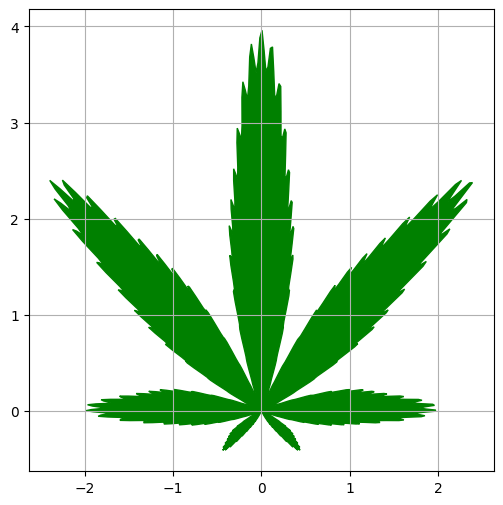

In [3]:
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
rho = (1 + 0.9 * torch.cos(8 * theta)) * (1 + 0.1 * torch.cos(24 * theta)) * (0.9 + 0.05 * torch.cos(200 * theta)) * (1 + torch.sin(theta))

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them.
x = rho * torch.cos(theta)
y = rho * torch.sin(theta)


plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

### Task II: The Game of Life

Now it's time for you to make something more challenging. We'll implement Conway's [Game of Life](http://web.stanford.edu/~cdebs/GameOfLife/) in _pure PyTorch_.

While this is still a toy task, implementing game of life this way has one cool benefit: __you'll be able to run it on GPU!__ Indeed, what could be a better use of your GPU than simulating Game of Life on 1M/1M grids?

![img](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

If you've skipped the URL above out of sloth, here's the Game of Life:
* You have a 2D grid of cells, where each cell is "alive"(1) or "dead"(0)
* Any living cell that has 2 or 3 neighbors survives, else it dies [0,1 or 4+ neighbors]
* Any cell with exactly 3 neighbors becomes alive (if it was dead)

For this task, you are given a reference NumPy implementation that you must convert to PyTorch.
_[NumPy code inspired by: https://github.com/rougier/numpy-100]_


__Note:__ You can find convolution in `torch.nn.functional.conv2d(Z,filters)`. Note that it has a different input format.

__Note 2:__ From the mathematical standpoint, PyTorch convolution is actually cross-correlation. Those two are very similar operations. More info: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](http://programmerz.ru/questions/26903/2d-convolution-in-python-similar-to-matlabs-conv2-question), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [4]:
from scipy.signal import correlate2d

def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [9]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.

    You can opt to create new tensor or change Z inplace.
    """

    filters = torch.tensor([[1., 1., 1.],
                            [1., 0., 1.],
                            [1., 1., 1.]], dtype=Z.dtype, device=Z.device)

    N = F.conv2d(Z[None, None], filters[None, None], padding=1)[0, 0]

    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z = (birth | survive).to(Z.dtype)
    return Z


In [7]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor)

# your debug polygon :)
Z_new = torch_update(Z.clone())

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

Well done!


In [8]:
%matplotlib notebook
plt.ion()

# initialize game field
Z = np.random.choice([0, 1], size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(100):
    # update
    Z = torch_update(Z)

    # re-draw image
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

<IPython.core.display.Javascript object>

In [10]:
# Some fun setups for your amusement

# parallel stripes
Z = np.arange(100) % 2 + np.zeros([100, 100])
# with a small imperfection
Z[48:52, 50] = 1

Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(100):
    Z = torch_update(Z)
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

<IPython.core.display.Javascript object>

More fun with Game of Life: [video](https://www.youtube.com/watch?v=C2vgICfQawE) and/or [Jupyter Notebook](https://nbviewer.jupyter.org/url/norvig.com/ipython/Life.ipynb)

### Task III: Going deeper
<img src="https://www.meme-arsenal.com/memes/00ad90d844e491aaeb6892515c716710.jpg" width=360>

Your third trial is to build your first neural network [almost] from scratch and pure PyTorch.

This time you will solve yet another digit recognition problem, but at a greater scale

* 10 different letters
* 20k samples

We want you to build a network that reaches at least 80% accuracy and has at least 2 linear layers in it. Naturally, it should be nonlinear to beat logistic regression.


With 10 classes you will need to use __Softmax__ at the top instead of sigmoid and train using __categorical crossentropy__ .  Write your own loss or use `torch.nn.functional.nll_loss`. Just make sure you understand what it accepts as input.

Note that you are not required to build 152-layer monsters here. A 2-layer (one hidden, one output) neural network should already give you an edge over logistic regression.


__[bonus kudos]__
If you've already beaten logistic regression with a two-layer net, but enthusiasm still ain't gone, you can try improving the test accuracy even further! It should be possible to reach 90% without convnets.

__SPOILERS!__
At the end of the notebook you will find a few tips and frequent errors.
If you feel confident enough, just start coding right away and get there ~~if~~ once you need to untangle yourself.

In [11]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall21/week02_autodiff/notmnist.py

In [12]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Extracting ...
Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

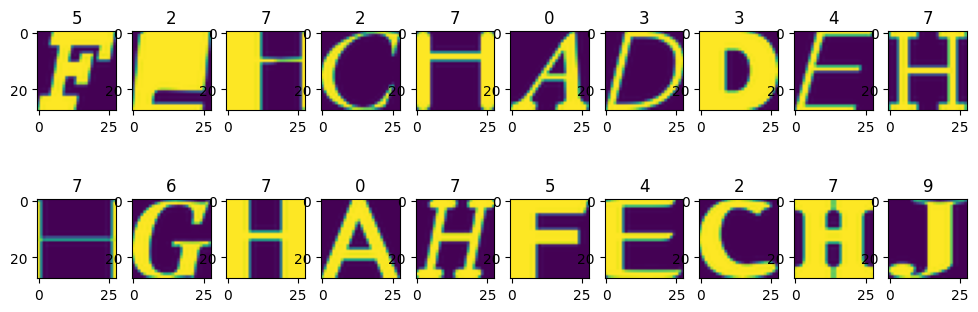

In [13]:
%matplotlib inline
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_tr = torch.tensor(X_train, dtype=torch.float32, device=device)
y_tr = torch.tensor(y_train, dtype=torch.long, device=device)
X_te = torch.tensor(X_test, dtype=torch.float32, device=device)
y_te = torch.tensor(y_test, dtype=torch.long, device=device)

n_features, n_classes = X_tr.shape[1], 10


@torch.no_grad()
def accuracy(forward, X, y):
    if isinstance(forward, nn.Module):
        forward.eval()
    return (forward(X).argmax(dim=1) == y).float().mean().item()


def train(forward, params, n_epochs=10, batch_size=256, lr=1e-3):
    opt = torch.optim.Adam(params, lr=lr)
    for epoch in range(n_epochs):
        if isinstance(forward, nn.Module):
            forward.train()
        perm = torch.randperm(len(X_tr), device=device)   # reshuffle every epoch
        losses = []
        for start in range(0, len(X_tr) - batch_size + 1, batch_size):
            ix = perm[start:start + batch_size]
            log_probs = F.log_softmax(forward(X_tr[ix]), dim=1)
            # pick log P(correct class) for each sample
            loss = -log_probs[torch.arange(batch_size, device=device), y_tr[ix]].mean()

            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        print(f"epoch {epoch:2d} | loss {np.mean(losses):.3f} | "
              f"train acc {accuracy(forward, X_tr, y_tr):.4f} | "
              f"test acc {accuracy(forward, X_te, y_te):.4f}")

W = torch.zeros(n_features, n_classes, device=device, requires_grad=True)
b = torch.zeros(n_classes, device=device, requires_grad=True)

def logreg(x):
    return x @ W + b          # logits, softmax is applied inside train

train(logreg, [W, b], n_epochs=10)


hidden = 50

W1 = (torch.randn(n_features, hidden, device=device) / n_features ** 0.5).requires_grad_()
b1 = torch.zeros(hidden, device=device, requires_grad=True)
W2 = (torch.randn(hidden, n_classes, device=device) / hidden ** 0.5).requires_grad_()
b2 = torch.zeros(n_classes, requires_grad=True)

def mlp(x):
    h = torch.sigmoid(x @ W1 + b1)
    return h @ W2 + b2

train(mlp, [W1, b1, W2, b2], n_epochs=20)



model = nn.Sequential(
    nn.Linear(784, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, n_classes),
).to(device)

train(model, model.parameters(), n_epochs=30)

epoch  0 | loss 0.775 | train acc 0.8757 | test acc 0.8648
epoch  1 | loss 0.463 | train acc 0.8878 | test acc 0.8780
epoch  2 | loss 0.425 | train acc 0.8945 | test acc 0.8825
epoch  3 | loss 0.405 | train acc 0.9006 | test acc 0.8859
epoch  4 | loss 0.390 | train acc 0.9037 | test acc 0.8872
epoch  5 | loss 0.379 | train acc 0.9067 | test acc 0.8874
epoch  6 | loss 0.371 | train acc 0.9085 | test acc 0.8870
epoch  7 | loss 0.365 | train acc 0.9090 | test acc 0.8866
epoch  8 | loss 0.359 | train acc 0.9121 | test acc 0.8889
epoch  9 | loss 0.351 | train acc 0.9127 | test acc 0.8859
epoch  0 | loss 1.333 | train acc 0.8589 | test acc 0.8532
epoch  1 | loss 0.756 | train acc 0.8773 | test acc 0.8690
epoch  2 | loss 0.570 | train acc 0.8896 | test acc 0.8799
epoch  3 | loss 0.479 | train acc 0.8961 | test acc 0.8870
epoch  4 | loss 0.426 | train acc 0.9023 | test acc 0.8923
epoch  5 | loss 0.393 | train acc 0.9085 | test acc 0.8932
epoch  6 | loss 0.366 | train acc 0.9111 | test acc 0.89

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

# SPOILERS!

Recommended pipeline:

* Adapt logistic regression from seminar assignment to classify one letter against others (e.g. A vs the rest)
* Generalize it to multiclass logistic regression.
  - Either try to remember lecture 0 or google it.
  - Instead of weight vector you'll have to use matrix (feature_id x class_id)
  - Softmax (exp over sum of exps) can be implemented manually or as `nn.Softmax` (layer) or `F.softmax` (function)
  - Probably better to use STOCHASTIC gradient descent (minibatch) for greater speed
    - You can also try momentum/rmsprop/adawhatever
    - in which case the dataset should probably be shuffled (or use random subsamples on each iteration)
* Add a hidden layer. Now your logistic regression uses hidden neurons instead of inputs.
  - Hidden layer uses the same math as output layer (ex-logistic regression), but uses some nonlinearity (e.g. sigmoid) instead of softmax
  - You need to train both layers, not just the output layer :)
  - 50 hidden neurons and a sigmoid nonlinearity will do for a start. Many ways to improve.
  - In ideal case this totals to 2 `torch.matmul`'s, 1 softmax and 1 ReLU/sigmoid
  - __Make sure this neural network works better than logistic regression!__

* Now's the time to try improving the network. Consider layers (size, neuron count), nonlinearities, optimization methods, initialization — whatever you want, but please avoid convolutions for now.

* If anything seems wrong, try going through one step of training and printing everything you compute.
* If you see NaNs midway through optimization, you can estimate $\log P(y \mid x)$ as `F.log_softmax(layer_before_softmax)`.